Cell migration analysis: step 1, automatic segmentation by cellpose

In [1]:
import os
import tifffile as tiff
from matplotlib import pyplot as plt
from cellpose import models, io
import numpy as np

def segment_all_frames(img):
    # Segmentation
    imgs = [img[i,:,:] for i in range(img.shape[0])]
    # Run cellpose
    model = models.CellposeModel(gpu=True)
    masks, flows, styles = model.eval(imgs)
    # Save masks as tif
    masks_all = np.stack(masks, axis=0)
    return masks_all

project_dir = "D:\\Kou - Trunk Neural Crest 2D\\project-01"

In [3]:

for sub_id in range(27):
    if sub_id == 0:
        continue
    if sub_id < 17:
        continue
    print(f'Processing sub {sub_id}...')
    data_path = os.path.join(project_dir, f"sub-{sub_id:03d}", f"sub-{sub_id:03d}_data-xyProjection.tif")
    membrane_mask_path = os.path.join(project_dir, f"sub-{sub_id:03d}", f"sub-{sub_id:03d}_data-memMask.tif")
    nucleus_mask_path = os.path.join(project_dir, f"sub-{sub_id:03d}", f"sub-{sub_id:03d}_data-nucMask.tif")

    image = tiff.imread(data_path)
    img_ch0 = image[:,0,:,:]
    img_ch1 = image[:,1,:,:]

    masks_all = segment_all_frames(img_ch1)
    tiff.imwrite(nucleus_mask_path, masks_all.astype(np.uint16))
 
    masks_all = segment_all_frames(img_ch0)
    tiff.imwrite(membrane_mask_path, masks_all.astype(np.uint16))

Processing sub 17...
Processing sub 18...
Processing sub 19...
Processing sub 20...
Processing sub 21...
Processing sub 22...
Processing sub 23...
Processing sub 24...
Processing sub 25...
Processing sub 26...


Text(0.5, 1.0, 'Channel 1')

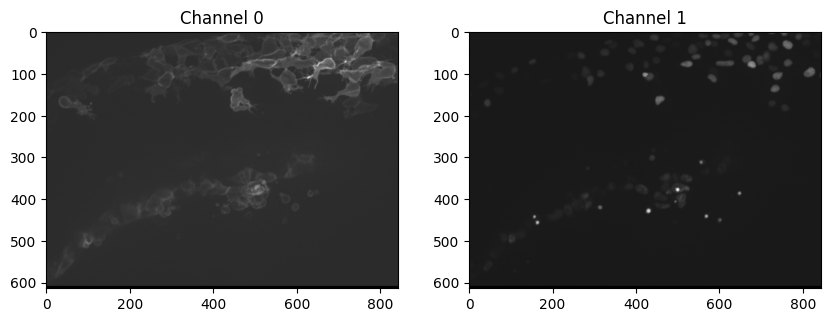

In [18]:
# Read the tif file
image = tiff.imread(data_path)
# Split the channels
img_ch0 = image[:,0,:,:]
img_ch1 = image[:,1,:,:]
# Visualize one slice of each channel
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_ch0[10,:,:], cmap='gray')
axes[0].set_title('Channel 0')
axes[1].imshow(img_ch1[10,:,:], cmap='gray')
axes[1].set_title('Channel 1')

In [20]:
image.shape

(161, 2, 614, 844)

Below, membrane segmentation

In [13]:
# Segmentation
imgs = [img_ch0[i,:,:] for i in range(img_ch0.shape[0])]
# Run cellpose
from cellpose import models, io
model = models.CellposeModel(gpu=True)
masks, flows, styles = model.eval(imgs)

# Save masks as tif
import numpy as np

masks_all = np.stack(masks, axis=0)

tiff.imwrite(membrane_mask_path, masks_all.astype(np.uint16))